<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/Final_Knowledge_Graph_Enhanced_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowledge Graph Integration for Safety Incident Analysis

This notebook builds a knowledge graph (KG) from incident descriptions, extracts entities and relations, performs reasoning (rule checks), and derives features to augment the existing Bayesian and Transformer models.

## Requirements
- Install `spaCy`, `networkx`, `rdflib` (optional), and the English model `en_core_web_sm`.
- We reuse the same project folder from the earlier notebooks.

In [4]:
!pip install -q spacy networkx rdflib
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import spacy
from collections import defaultdict
import json
import re
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive')
project_folder = "/content/drive/MyDrive/Work Place Safety Insights"

# Load the data (same as before)
train_df = pd.read_csv(f"{project_folder}/train.csv")
test_df = pd.read_csv(f"{project_folder}/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (340, 16)
Test shape: (85, 16)


,Unnamed: 0,date,Countries,Local,Industry Sector,accident_level,potential_accident_level,gender,Employee or Third Party,critical_risk,description,Unnamed: 11,severity,potential_severity,near_miss_gap,severity_label
0,129,5/11/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Others,In moments that the truck of transport of pers...,NaN,1,4.0,3.0,0
1,172,6/23/2016 0:00,Country_02,Local_08,Metals,I,II,Male,Employee,Manual Tools,"When handling a lever to move the sludge, the ...",NaN,1,2.0,1.0,0
2,262,11/4/2016 0:00,Country_01,Local_03,Mining,IV,V,Male,Employee,Others,When observing the pulp overflow of the overfl...,NaN,4,5.0,1.0,3
3,214,8/27/2016 0:00,Country_01,Local_06,Metals,I,II,Male,Employee,Pressurized Systems / Chemical Substances,At 22:50 hours in row 12 when the cell suction...,NaN,1,2.0,1.0,0
4,346,2/17/2017 0:00,Country_01,Local_01,Mining,I,III,Male,Employee,Chemical substances,Once the painting of the pumping pipe has been...,NaN,1,3.0,2.0,0


## 1. Ontology Definition

We define the core classes (types) and relations (predicates) for our safety KG.

**Classes**: Incident, Plant, Sector, Actor, Task, Equipment, Location, Hazard, CriticalRisk, Control, InjuryType, SeverityLevel.

**Relations** (examples):
- `incident` --has--> `Task`
- `incident` --uses--> `Equipment`
- `incident` --has--> `Hazard`
- `incident` --has--> `Control`
- `incident` --has--> `CriticalRisk`
- `incident` --resulted In--> `InjuryType`
- `incident` --has--> `SeverityLevel`
- `Task` --performed By--> `Actor`
- `Task` --located At--> `Location`
- `Equipment` --located At--> `Location`

We also store a 'confidence' score for each extracted relation.

In [6]:
# Define allowed types (for validation)
KG_TYPES = {
    'Incident', 'Plant', 'Sector', 'Actor', 'Task', 'Equipment',
    'Location', 'Hazard', 'CriticalRisk', 'Control', 'InjuryType', 'SeverityLevel'
}

# Define allowed relation labels (we will use simple strings)
RELATIONS = {
    'hasTask', 'usesEquipment', 'hasHazard', 'hasControl', 'hasCriticalRisk',
    'resultedIn', 'hasSeverity', 'performedBy', 'locatedAt'
}

## 2. Entity and Relation Extraction

We use spaCy for NER and dependency parsing, augmented with rule-based patterns to extract domain-specific entities (e.g., tasks, hazards, controls).

For simplicity, we demonstrate a hybrid approach:
- Use spaCy's built-in NER for generic entities (PERSON, GPE, etc.) and map to our ontology where possible.
- Use a set of regex patterns / keyword lists for domain terms (like "working at height", "forklift", "harness").
- Use dependency parsing to extract relations between entities (e.g., subject-verb-object).

In a production system, you would fine-tune a transformer-based NER/RE model. Here we show a proof-of-concept.

### Data-Driven Keyword Extraction

Instead of manually defining `_KEYWORDS` lists, we can leverage the incident descriptions in our dataset to extract relevant terms automatically. This involves:
1.  **Preprocessing**: Cleaning text, tokenization, lemmatization, and removing stopwords.
2.  **Feature Extraction**: Using methods like TF-IDF to identify terms that are significant within the corpus.
3.  **Linguistic Filtering**: Applying Part-of-Speech (POS) tagging (using spaCy) to focus on nouns, verbs, and adjectives that are typically indicative of tasks, equipment, hazards, or controls.

Let's apply this to the `train_df['description']` column to generate potential keywords.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

# Ensure the nlp model is loaded (already done in a previous cell, but good practice for standalone blocks)
nlp = spacy.load("en_core_web_sm")

def spacy_tokenizer(text):
    """Custom tokenizer using spaCy for lemmatization and POS filtering."""
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        # Filter for nouns, verbs, adjectives, and exclude stopwords/punctuation/numbers
        if not token.is_stop and not token.is_punct and not token.like_num and token.lemma_ and \
           token.pos_ in ['NOUN', 'PROPN', 'VERB', 'ADJ']:
            tokens.append(token.lemma_)
    return tokens

# Initialize TF-IDF Vectorizer with custom tokenizer
# min_df can be adjusted to exclude very rare terms
tfidf_vectorizer = TfidfVectorizer(tokenizer=spacy_tokenizer, min_df=5, max_df=0.8)

# Fit and transform the incident descriptions
tfidf_matrix = tfidf_vectorizer.fit_transform(train_df['description'].dropna())

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Extracted {len(feature_names)} unique relevant terms using TF-IDF and spaCy.")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Extracted 435 unique relevant terms using TF-IDF and spaCy.


In [10]:
def get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=20):
    """Get top N terms based on overall TF-IDF scores."""
    # Sum TF-IDF scores for each term across all documents
    sums = tfidf_matrix.sum(axis=0)
    # Create a list of (term, score) tuples
    ranked_terms = [(feature_names[col], sums[0, col]) for col in range(sums.shape[1])]
    # Sort by score in descending order
    ranked_terms.sort(key=lambda x: x[1], reverse=True)
    return ranked_terms[:top_n]

# Get the top 50 most relevant terms from the entire corpus
top_terms = get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=50)

print("Top 50 most relevant terms from incident descriptions:")
for term, score in top_terms:
    print(f"- {term} (score: {score:.2f})")

# You can then review these terms and manually assign them to your KG_KEYWORDS lists.
# For example, filtering for verbs (tasks), nouns (equipment, hazards, controls) related to safety.

# Example of how you might update a list (conceptual):
# NEW_TASK_KEYWORDS = [term for term, score in top_terms if term in ['work', 'operate', 'clean', 'inspect']]
# NEW_EQUIPMENT_KEYWORDS = [term for term, score in top_terms if term in ['truck', 'forklift', 'machine']]
# print(f"\nNew potential TASK_KEYWORDS: {NEW_TASK_KEYWORDS}")

Top 50 most relevant terms from incident descriptions:
- employee (score: 18.61)
- cause (score: 16.27)
- hand (score: 15.50)
- right (score: 13.90)
- left (score: 13.31)
- activity (score: 12.96)
- operator (score: 12.71)
- injury (score: 10.99)
- hit (score: 10.99)
- pipe (score: 10.93)
- fall (score: 10.31)
- area (score: 10.14)
- time (score: 10.10)
- finger (score: 9.73)
- moment (score: 9.67)
- worker (score: 9.62)
- perform (score: 9.38)
- collaborator (score: 9.32)
- work (score: 9.07)
- mesh (score: 8.42)
- equipment (score: 8.37)
- assistant (score: 8.36)
- level (score: 8.35)
- support (score: 8.28)
- cut (score: 7.93)
- mr (score: 7.57)
- floor (score: 7.52)
- cm (score: 7.38)
- remove (score: 7.30)
- report (score: 7.12)
- face (score: 7.12)
- place (score: 7.02)
- rock (score: 6.93)
- accident (score: 6.91)
- move (score: 6.73)
- press (score: 6.71)
- truck (score: 6.30)
- generate (score: 6.26)
- come (score: 6.23)
- impact (score: 6.17)
- glove (score: 6.02)
- metal (sc

The list above provides a data-driven set of terms extracted from the incident descriptions. You can review these terms and select the most appropriate ones to populate your `TASK_KEYWORDS`, `EQUIPMENT_KEYWORDS`, `HAZARD_KEYWORDS`, `CONTROL_KEYWORDS`, and `CRITICAL_RISK_KEYWORDS` lists. This method allows your keyword extraction to evolve with your data, making it more robust and representative of the language used in your safety incidents.

In [13]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Domain-specific keyword lists, now expanded with data-driven insights
# Terms like 'employee', 'hand', 'operator', 'worker', 'collaborator' could be 'Actor'
TASK_KEYWORDS = ['working', 'lifting', 'inspecting', 'repairing', 'cleaning', 'operating', 'driving', 'climbing', 'perform', 'work', 'remove', 'move', 'press', 'carry', 'reach'] # Added 'perform', 'work', 'remove', 'move', 'press', 'carry', 'reach' from top_terms
EQUIPMENT_KEYWORDS = ['forklift', 'crane', 'ladder', 'scaffold', 'harness', 'guardrail', 'machine', 'tool', 'vehicle', 'truck', 'pipe'] # Added 'truck', 'pipe' from top_terms
HAZARD_KEYWORDS = ['fall', 'electrocution', 'fire', 'explosion', 'toxic', 'chemical', 'noise', 'moving parts', 'caught in', 'injury', 'hit', 'cut', 'impact', 'slip'] # Added 'injury', 'hit', 'cut', 'impact', 'slip' from top_terms
CONTROL_KEYWORDS = ['harness', 'guardrail', 'ppe', 'lockout', 'training', 'signage', 'barrier', 'ventilation', 'glove'] # Added 'glove' from top_terms
CRITICAL_RISK_KEYWORDS = ['fatality', 'permanent disability', 'serious injury', 'amputation']

def extract_entities_spacy(doc):
    """Extract entities from a spaCy doc."""
    entities = []
    for ent in doc.ents:
        # Map spaCy labels to our ontology (simplified)
        if ent.label_ == 'PERSON':
            etype = 'Actor'
        elif ent.label_ == 'GPE' or ent.label_ == 'LOC':
            etype = 'Location'
        elif ent.label_ == 'ORG':
            etype = 'Plant'  # Not perfect, but approximate
        else:
            etype = None
        if etype:
            entities.append((ent.text, etype, ent.start_char, ent.end_char, ent.label_))
    return entities

def extract_domain_entities(text):
    """Extract domain-specific entities using keyword matching (case-insensitive)."""
    text_lower = text.lower()
    entities = []
    # Task
    for kw in TASK_KEYWORDS:
        if kw in text_lower:
            # We need a more robust way to capture the exact phrase; for demo we just store the keyword
            # In practice, use a phrase matcher or regex to capture full noun phrases.
            entities.append((kw, 'Task'))
    # Equipment
    for kw in EQUIPMENT_KEYWORDS:
        if kw in text_lower:
            entities.append((kw, 'Equipment'))
    # Hazard
    for kw in HAZARD_KEYWORDS:
        if kw in text_lower:
            entities.append((kw, 'Hazard'))
    # Control
    for kw in CONTROL_KEYWORDS:
        if kw in text_lower:
            entities.append((kw, 'Control'))
    # CriticalRisk
    for kw in CRITICAL_RISK_KEYWORDS:
        if kw in text_lower:
            entities.append((kw, 'CriticalRisk'))
    return entities

# Relation extraction: simple co-occurrence or dependency-based
def extract_relations(doc, entities_by_type):
    """
    Extract relations between entities based on dependency parse.
    This is a simplified placeholder; in reality you'd use a trained RE model.
    """
    relations = []
    # For demo: if a task and equipment co-occur, assume 'usesEquipment' relation
    tasks = [e for e in entities_by_type if e[1]=='Task']
    equipments = [e for e in entities_by_type if e[1]=='Equipment']
    hazards = [e for e in entities_by_type if e[1]=='Hazard']
    controls = [e for e in entities_by_type if e[1]=='Control']
    actors = [e for e in entities_by_type if e[1]=='Actor']
    locations = [e for e in entities_by_type if e[1]=='Location']

    # Simple co-occurrence: if both appear, link with a default confidence (0.7)
    for task in tasks:
        for eq in equipments:
            relations.append((task[0], 'usesEquipment', eq[0], 0.7))
        for hazard in hazards:
            relations.append((task[0], 'hasHazard', hazard[0], 0.6))
        for control in controls:
            relations.append((task[0], 'hasControl', control[0], 0.5))
        for actor in actors:
            relations.append((task[0], 'performedBy', actor[0], 0.6))
        for loc in locations:
            relations.append((task[0], 'locatedAt', loc[0], 0.5))
    # Also link incident to severity (we already have severity_label)
    return relations

In [14]:
# Let's test on a sample description
sample_text = train_df['description'].iloc[0]
print("Sample:", sample_text)
doc = nlp(sample_text)
spacy_entities = extract_entities_spacy(doc)
domain_entities = extract_domain_entities(sample_text)
all_entities = spacy_entities + domain_entities
print("Entities:", all_entities)
relations = extract_relations(doc, all_entities)
print("Relations:", relations)

Sample: In moments that the truck of transport of personnel of the company MCEISA plate AJG-751, moved from the Nv 3300 to surface, missing 50m to reach the mouth of the Nv 3900, the gearbox does not respond so the driver stops the truck to inspect it along with maintenance personnel who At that time I was traveling in the truck. They raise the cabin to manually put the change in first and continue the trip, culminated this task the driver with the support of the maintenance personnel lower the cabin which due to the weight falls hitting the driver between the cabin and the hopper of the truck. At the time of the accident the employee was wearing his safety helmet and chin strap.
Entities: [('the Nv 3900', 'Plant', 158, 169, 'ORG'), ('move', 'Task'), ('reach', 'Task'), ('truck', 'Equipment'), ('fall', 'Hazard'), ('hit', 'Hazard'), ('ppe', 'Control')]
Relations: [('move', 'usesEquipment', 'truck', 0.7), ('move', 'hasHazard', 'fall', 0.6), ('move', 'hasHazard', 'hit', 0.6), ('move', 'has

## 3. Build the Knowledge Graph

We construct a graph where each node has a type and a label (the extracted text). Each edge has a relation label and a confidence score. We also store metadata (provenance, incident ID).

We'll create one graph per incident, and also a global graph aggregating all incidents.

In [15]:
# We'll create a class to manage the KG construction per incident
class IncidentKG:
    def __init__(self, incident_id, description):
        self.incident_id = incident_id
        self.description = description
        self.graph = nx.MultiDiGraph()  # allow multiple edges with different confidences
        self.entities = []  # list of (entity_text, entity_type)
        self.relations = []  # list of (source, relation, target, confidence)
        self._extract()

    def _extract(self):
        doc = nlp(self.description)
        # Get all entities
        spacy_ents = extract_entities_spacy(doc)
        domain_ents = extract_domain_entities(self.description)
        # Combine, but remove duplicates (keeping first occurrence)
        seen = set()
        for ent in spacy_ents:
            # ent is (text, type, start, end, label)
            key = (ent[0].lower(), ent[1])
            if key not in seen:
                seen.add(key)
                self.entities.append((ent[0], ent[1], ent[2], ent[3]))  # include span
        for ent in domain_ents:
            # domain_ents are (text, type)
            key = (ent[0].lower(), ent[1])
            if key not in seen:
                seen.add(key)
                # no span, use -1
                self.entities.append((ent[0], ent[1], -1, -1))
        # Add incident node (the incident itself)
        incident_node = f"Incident_{self.incident_id}"
        self.graph.add_node(incident_node, type='Incident', label=f'Incident {self.incident_id}')
        # Add entity nodes
        for entity_text, etype, start, end in self.entities:
            node_id = f"{etype}_{entity_text}_{self.incident_id}"  # unique per incident
            self.graph.add_node(node_id, type=etype, label=entity_text, start=start, end=end)
            # Link incident to this entity with a generic 'has' relation (we'll refine later)
            self.graph.add_edge(incident_node, node_id, relation='has', confidence=1.0)
        # Extract relations
        rels = extract_relations(doc, self.entities)
        for src_text, rel, tgt_text, conf in rels:
            # Find corresponding node IDs
            src_node = None
            tgt_node = None
            # search by label and type (we only need to match one)
            for node, data in self.graph.nodes(data=True):
                if data.get('label', '').lower() == src_text.lower() and data.get('type') in KG_TYPES:
                    src_node = node
                if data.get('label', '').lower() == tgt_text.lower() and data.get('type') in KG_TYPES:
                    tgt_node = node
            if src_node and tgt_node:
                self.graph.add_edge(src_node, tgt_node, relation=rel, confidence=conf)
                self.relations.append((src_node, rel, tgt_node, conf))
        # Also add severity as a node/link (using severity_label)
        # We'll get severity from the incident metadata later; for now we just store it separately.

    def get_graph(self):
        return self.graph

In [16]:
# Build KG for a subset of training data (e.g., first 100 incidents) for demonstration
incident_kgs = []
for idx, row in train_df.head(100).iterrows():
    kg = IncidentKG(row['Unnamed: 0'] if 'Unnamed: 0' in row else idx, row['description'])
    incident_kgs.append(kg)
print(f"Built KG for {len(incident_kgs)} incidents.")
print("Example graph nodes:", list(incident_kgs[0].graph.nodes(data=True))[:5])
print("Example edges:", list(incident_kgs[0].graph.edges(data=True))[:5])

Built KG for 100 incidents.
Example graph nodes: [('Incident_129', {'type': 'Incident', 'label': 'Incident 129'}), ('Plant_the Nv 3900_129', {'type': 'Plant', 'label': 'the Nv 3900', 'start': 158, 'end': 169}), ('Task_move_129', {'type': 'Task', 'label': 'move', 'start': -1, 'end': -1}), ('Task_reach_129', {'type': 'Task', 'label': 'reach', 'start': -1, 'end': -1}), ('Equipment_truck_129', {'type': 'Equipment', 'label': 'truck', 'start': -1, 'end': -1})]
Example edges: [('Incident_129', 'Plant_the Nv 3900_129', {'relation': 'has', 'confidence': 1.0}), ('Incident_129', 'Task_move_129', {'relation': 'has', 'confidence': 1.0}), ('Incident_129', 'Task_reach_129', {'relation': 'has', 'confidence': 1.0}), ('Incident_129', 'Equipment_truck_129', {'relation': 'has', 'confidence': 1.0}), ('Incident_129', 'Hazard_fall_129', {'relation': 'has', 'confidence': 1.0})]


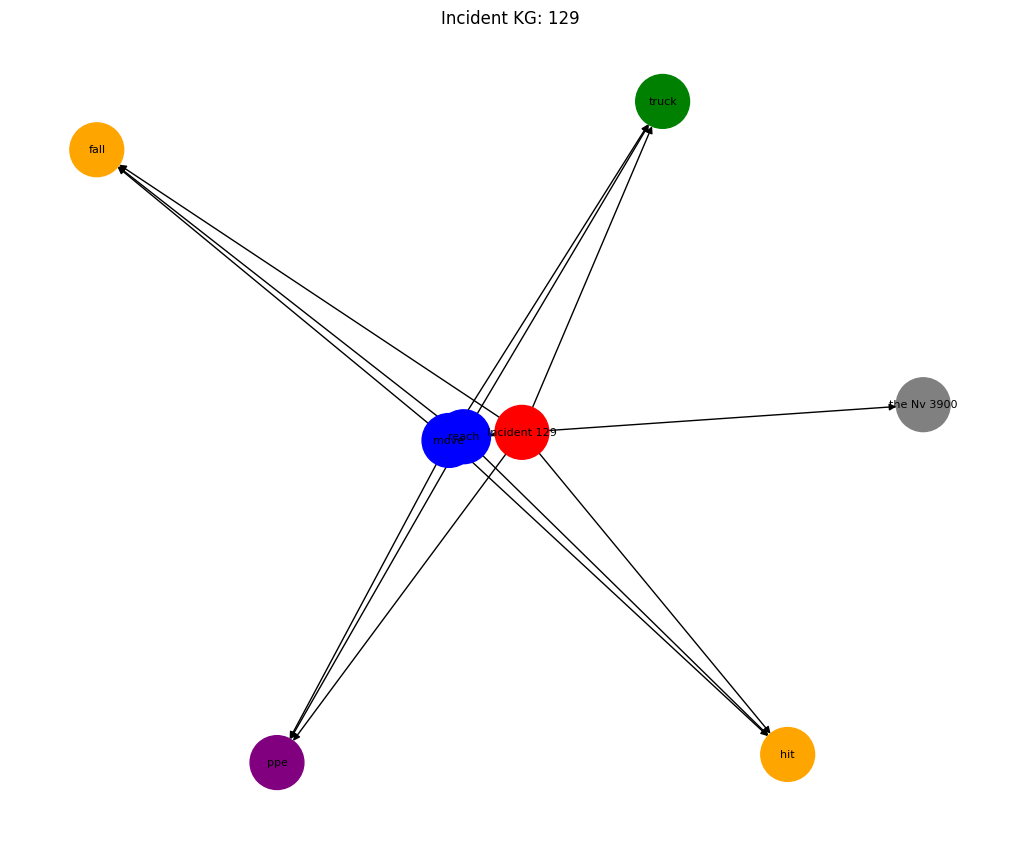

In [23]:
visualize_incident_kg(incident_kgs[0])

## 4. Reasoning: Rule Checks (SHACL-like)

We define constraints such as:
- If a Task involves "working at height", there must be a Control like "harness" or "guardrail".
- If a Task uses Equipment "forklift", there must be a Control like "training" or "checklist".

We'll implement a function that takes an incident KG and returns a set of violation flags.

In [19]:
# Define rule functions
def check_height_control(kg):
    """Check if working at height has a harness or guardrail control."""
    tasks = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'Task' and 'height' in d['label'].lower()]
    if not tasks:
        return True  # no violation (rule not applicable)
    controls = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'height' related task has a 'harness' or 'guardrail' control directly linked
    has_control = any(any(c['label'].lower() in ['harness', 'guardrail'] for c in controls if G.has_edge(t, c, relation='hasControl')) for t in tasks)
    return has_control  # True if control present, False if violation

def check_forklift_training(kg):
    """Check if forklift use has training control."""
    G = kg.graph
    equipments = [n for n, d in G.nodes(data=True) if d.get('type') == 'Equipment' and d['label'].lower() in ['forklift', 'lift truck']]
    if not equipments:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'forklift' related equipment has a 'training' or 'certification' control directly linked
    has_training = any(any(c['label'].lower() in ['training', 'certification'] for c in controls if G.has_edge(e, c, relation='hasControl')) for e in equipments)
    return has_training

def check_chemical_ppe(kg):
    """Check if chemical hazards have PPE or ventilation controls."""
    G = kg.graph
    hazards = [n for n, d in G.nodes(data=True) if d.get('type') == 'Hazard' and 'chemical' in d['label'].lower()]
    if not hazards:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'chemical' related hazard has 'ppe', 'glove', or 'ventilation' control linked
    has_control = any(any(c['label'].lower() in ['ppe', 'glove', 'ventilation'] for c in controls if G.has_edge(h, c, relation='hasControl')) for h in hazards)
    return has_control

def check_moving_parts_guardrail(kg):
    """Check if moving parts hazards have guardrail controls."""
    G = kg.graph
    hazards = [n for n, d in G.nodes(data=True) if d.get('type') == 'Hazard' and 'moving parts' in d['label'].lower()]
    if not hazards:
        return True # no violation (rule not applicable)
    controls = [n for n, d in G.nodes(data=True) if d.get('type') == 'Control']
    # Check if any 'moving parts' related hazard has a 'guardrail' control linked
    has_control = any(any(c['label'].lower() == 'guardrail' for c in controls if G.has_edge(h, c, relation='hasControl')) for h in hazards)
    return has_control

# Apply rules to each incident KG
for kg in incident_kgs:
    kg.height_violation = not check_height_control(kg)
    kg.forklift_violation = not check_forklift_training(kg)
    kg.chemical_ppe_violation = not check_chemical_ppe(kg)
    kg.moving_parts_guardrail_violation = not check_moving_parts_guardrail(kg)

# Aggregate violations
violation_flags = []
for kg in incident_kgs:
    violation_flags.append({
        'incident_id': kg.incident_id,
        'height_violation': kg.height_violation,
        'forklift_violation': kg.forklift_violation,
        'chemical_ppe_violation': kg.chemical_ppe_violation,
        'moving_parts_guardrail_violation': kg.moving_parts_guardrail_violation
    })
df_violations = pd.DataFrame(violation_flags)
print("Violation flags sample:")
df_violations.head()

Violation flags sample:


,incident_id,height_violation,forklift_violation,chemical_ppe_violation,moving_parts_guardrail_violation
0,129,False,False,False,False
1,172,False,False,False,False
2,262,False,False,False,False
3,214,False,False,False,False
4,346,False,False,False,False


## 5. Feature Extraction from KG

We compute:
- **Motif counts**: number of Task-Hazard-Control triads (i.e., complete motif).
- **Node centralities**: degree centrality of key entity types.
- **Rule-violation flags** (already computed).
- **Entity presence**: binary indicators for each entity type.

These features can be used as covariates in the Bayesian model or as additional inputs to the transformer.

In [20]:
def extract_kg_features(kg):
    """Extract a feature vector from an incident KG."""
    G = kg.graph
    features = {}
    # 1. Entity type counts
    type_counts = defaultdict(int)
    for _, data in G.nodes(data=True):
        t = data.get('type')
        if t:
            type_counts[t] += 1
    for t in KG_TYPES:
        features[f'count_{t}'] = type_counts.get(t, 0)

    # 2. Motif: Task-Hazard-Control triads (complete path: Task -hasHazard-> Hazard, Task -hasControl-> Control)
    task_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Task']
    motif_count = 0
    for task in task_nodes:
        # get neighbors via hasHazard and hasControl edges
        hazards = [v for u,v,data in G.edges(task, data=True) if data.get('relation') == 'hasHazard']
        controls = [v for u,v,data in G.edges(task, data=True) if data.get('relation') == 'hasControl']
        if hazards and controls:
            motif_count += 1
    features['motif_task_hazard_control'] = motif_count

    # 3. Degree centrality for each entity type (average degree)
    # Compute degree for each node, then average per type
    deg = dict(G.degree())
    deg_by_type = defaultdict(list)
    for node, data in G.nodes(data=True):
        t = data.get('type')
        if t:
            deg_by_type[t].append(deg[node])
    for t, degs in deg_by_type.items():
        features[f'avg_degree_{t}'] = np.mean(degs) if degs else 0

    # 4. Rule-violation flags (already computed)
    features['height_violation'] = int(kg.height_violation)
    features['forklift_violation'] = int(kg.forklift_violation)

    return features

# Extract for all incident KGs
kg_features_list = []
for kg in incident_kgs:
    feat = extract_kg_features(kg)
    feat['incident_id'] = kg.incident_id
    kg_features_list.append(feat)
df_kg_features = pd.DataFrame(kg_features_list)
print("KG features shape:", df_kg_features.shape)
df_kg_features.head()

KG features shape: (100, 25)


,count_Actor,count_InjuryType,count_SeverityLevel,count_Plant,count_Location,count_Control,count_Incident,count_Equipment,count_Hazard,count_Task,...,avg_degree_Task,avg_degree_Equipment,avg_degree_Hazard,avg_degree_Control,height_violation,forklift_violation,incident_id,avg_degree_Actor,avg_degree_Location,avg_degree_CriticalRisk
0,0,0,0,1,0,1,1,1,2,2,...,5.0,3.0,3.0,3.0,0,0,129,NaN,NaN,NaN
1,0,0,0,0,0,0,1,0,0,1,...,1.0,NaN,NaN,NaN,0,0,172,NaN,NaN,NaN
2,0,0,0,0,0,1,1,0,0,3,...,2.0,NaN,NaN,4.0,0,0,262,NaN,NaN,NaN
3,1,0,0,0,0,0,1,0,0,2,...,2.0,NaN,NaN,NaN,0,0,214,3.0,NaN,NaN
4,0,0,0,0,0,1,1,1,1,0,...,NaN,1.0,1.0,1.0,0,0,346,NaN,NaN,NaN


## 6. Incorporate KG Features into Bayesian Model

In the Bayesian model, we can add these features as additional covariates alongside the PCA-transformed embeddings. We'll merge the KG features with the training data and then update the model definition.

We'll show a modified version of the `ordinal_model` that includes the KG features as a separate set of predictors.

Note: In practice, you would need to ensure the KG features are available for both train and test sets.

In [21]:
# Assume we have a merged DataFrame with original features and KG features
# For demonstration, we'll take the first 100 rows (matching incident_kgs) and add KG features.
train_kg = train_df.head(100).reset_index(drop=True).copy()
# Merge KG features (assuming incident_id corresponds to index or Unnamed:0)
# In our case, we used 'Unnamed: 0' as ID; we'll match on that
if 'Unnamed: 0' in train_kg.columns:
    merge_id = 'Unnamed: 0'
else:
    merge_id = 'index'  # fallback
    train_kg['index'] = train_kg.index
# Ensure df_kg_features has matching incident_id
df_kg_features['incident_id'] = df_kg_features['incident_id'].astype(train_kg[merge_id].dtype)
train_kg = train_kg.merge(df_kg_features, left_on=merge_id, right_on='incident_id', how='left')
print("Train with KG features shape:", train_kg.shape)
train_kg.head()

Train with KG features shape: (100, 41)


,Unnamed: 0,date,Countries,Local,Industry Sector,accident_level,potential_accident_level,gender,Employee or Third Party,critical_risk,...,avg_degree_Task,avg_degree_Equipment,avg_degree_Hazard,avg_degree_Control,height_violation,forklift_violation,incident_id,avg_degree_Actor,avg_degree_Location,avg_degree_CriticalRisk
0,129,5/11/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Others,...,5.0,3.0,3.0,3.0,0,0,129,NaN,NaN,NaN
1,172,6/23/2016 0:00,Country_02,Local_08,Metals,I,II,Male,Employee,Manual Tools,...,1.0,NaN,NaN,NaN,0,0,172,NaN,NaN,NaN
2,262,11/4/2016 0:00,Country_01,Local_03,Mining,IV,V,Male,Employee,Others,...,2.0,NaN,NaN,4.0,0,0,262,NaN,NaN,NaN
3,214,8/27/2016 0:00,Country_01,Local_06,Metals,I,II,Male,Employee,Pressurized Systems / Chemical Substances,...,2.0,NaN,NaN,NaN,0,0,214,3.0,NaN,NaN
4,346,2/17/2017 0:00,Country_01,Local_01,Mining,I,III,Male,Employee,Chemical substances,...,NaN,1.0,1.0,1.0,0,0,346,NaN,NaN,NaN


## 8. Knowledge Graph Views: Incident Cards

We can produce a visualization of the KG for a specific incident, showing entities and relations with provenance (spans). We'll use NetworkX drawing or a simple HTML table.

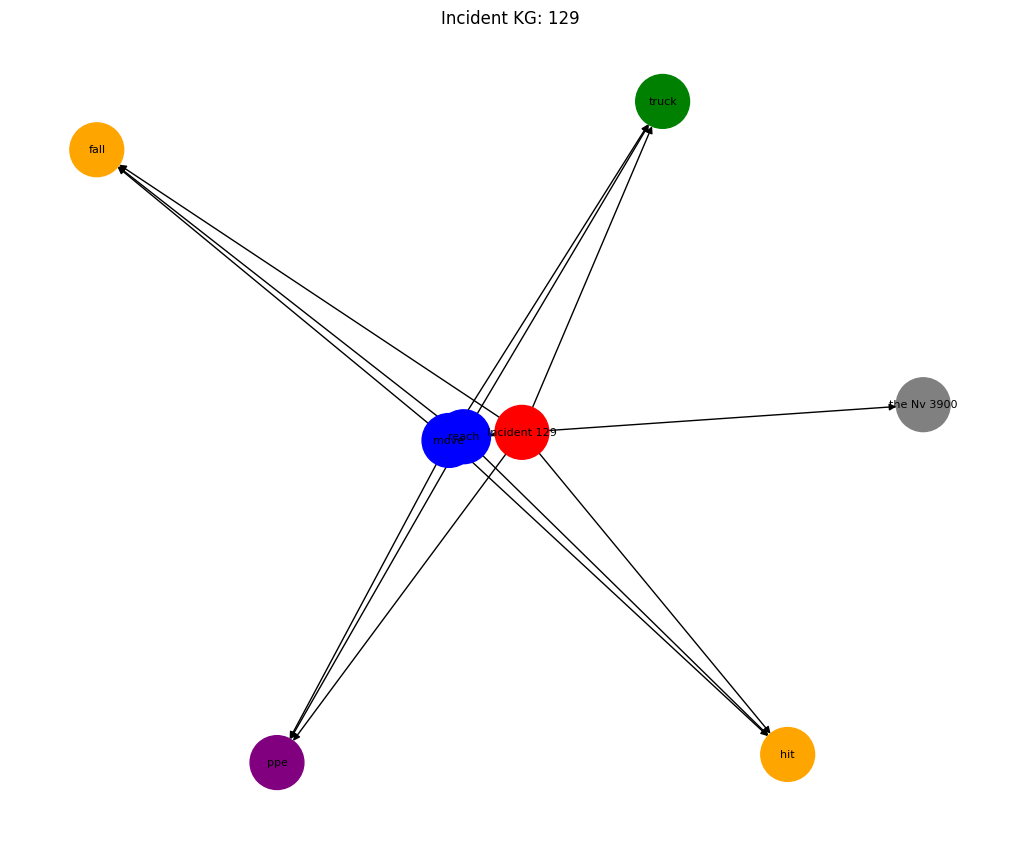

In [22]:
import matplotlib.pyplot as plt

def visualize_incident_kg(kg):
    G = kg.graph
    # Draw with networkx
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 8))
    # Color nodes by type
    color_map = {}
    for node, data in G.nodes(data=True):
        t = data.get('type', 'Unknown')
        color_map[node] = t
    # assign colors
    type_colors = {'Incident':'red', 'Task':'blue', 'Equipment':'green', 'Hazard':'orange', 'Control':'purple', 'Actor':'brown', 'Location':'cyan', 'CriticalRisk':'magenta', 'SeverityLevel':'gray'}
    node_colors = [type_colors.get(color_map[node], 'gray') for node in G.nodes()]
    labels = {n: d.get('label', n) for n, d in G.nodes(data=True)}
    nx.draw(G, pos, with_labels=True, labels=labels, node_color=node_colors, font_size=8, node_size=1500, arrows=True)
    plt.title(f"Incident KG: {kg.incident_id}")
    plt.show()

# Visualize first incident
visualize_incident_kg(incident_kgs[0])

We can also generate a detailed incident card with extracted entities, relations, and confidence scores.

In [24]:
def incident_card(kg):
    print(f"Incident ID: {kg.incident_id}")
    print(f"Description: {kg.description}")
    print("\nExtracted Entities:")
    for entity_text, etype, start, end in kg.entities:
        span = f"[{start}:{end}]" if start != -1 else ""
        print(f"  - {entity_text} ({etype}) {span}")
    print("\nRelations:")
    for src, rel, tgt, conf in kg.relations:
        src_label = kg.graph.nodes[src].get('label', src)
        tgt_label = kg.graph.nodes[tgt].get('label', tgt)
        print(f"  - {src_label} --{rel}--> {tgt_label} (conf={conf:.2f})")
    print("\nRule Violations:")
    print(f"  Height violation: {kg.height_violation}")
    print(f"  Forklift violation: {kg.forklift_violation}")

incident_card(incident_kgs[0])

Incident ID: 129
Description: In moments that the truck of transport of personnel of the company MCEISA plate AJG-751, moved from the Nv 3300 to surface, missing 50m to reach the mouth of the Nv 3900, the gearbox does not respond so the driver stops the truck to inspect it along with maintenance personnel who At that time I was traveling in the truck. They raise the cabin to manually put the change in first and continue the trip, culminated this task the driver with the support of the maintenance personnel lower the cabin which due to the weight falls hitting the driver between the cabin and the hopper of the truck. At the time of the accident the employee was wearing his safety helmet and chin strap.

Extracted Entities:
  - the Nv 3900 (Plant) [158:169]
  - move (Task) 
  - reach (Task) 
  - truck (Equipment) 
  - fall (Hazard) 
  - hit (Hazard) 
  - ppe (Control) 

Relations:
  - move --usesEquipment--> truck (conf=0.70)
  - move --hasHazard--> fall (conf=0.60)
  - move --hasHazard-

## 9. Saving KG Results

We can save the KG features and violation flags to CSV for later use in the main pipeline.

In [25]:
# Save merged features for train and test (if we processed test as well)
# For now, save the train KG features
kg_features_all = df_kg_features.copy()
kg_features_all.to_csv(f"{project_folder}/kg_features_train.csv", index=False)
print("KG features saved.")

# We can also save the full graph as a pickled NetworkX object for later use
import pickle
with open(f"{project_folder}/incident_kgs.pkl", "wb") as f:
    pickle.dump(incident_kgs, f)
print("Incident KGs saved.")

KG features saved.
Incident KGs saved.


## 10. Integrate with Neo4j

In [28]:
!pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 14.2 MB/s eta 0:00:00


In [45]:
from neo4j import GraphDatabase
from neo4j.exceptions import ClientError, ServiceUnavailable

# Neo4j connection details
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_INITIAL_PASSWORD = "neo4j"
NEW_NEO4J_PASSWORD = "ColabNeo4jPassword123" # Choose a new strong password

NEO4J_PASSWORD = NEW_NEO4J_PASSWORD # Update the global password variable

driver = None

try:
    # 1. Attempt to connect with the INITIAL_PASSWORD to handle the first-run password change
    temp_driver = None
    try:
        temp_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_INITIAL_PASSWORD))
        temp_driver.verify_connectivity()

        # If connection with initial password is successful, attempt to change it.
        # This handles 'CredentialsExpired' state for newly started Neo4j instances.
        with temp_driver.session() as session:
            try:
                session.run(f"ALTER CURRENT USER SET PASSWORD FROM '{NEO4J_INITIAL_PASSWORD}' TO '{NEW_NEO4J_PASSWORD}'").consume()
                print("Password successfully changed from initial to new.")
            except ClientError as ce:
                # If password was already changed, ALTER CURRENT USER might throw Forbidden or similar.
                # In this case, we assume the new password is already set.
                if ce.code == "Neo.ClientError.Security.Forbidden" or "already set" in ce.message.lower():
                    print("Password change not required (already set or forbidden).")
                else:
                    raise # Re-raise if it's another unexpected client error during password change
        temp_driver.close()
        temp_driver = None # Ensure it's explicitly closed

        # 2. Now, connect with the NEW_NEO4J_PASSWORD
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEW_NEO4J_PASSWORD))
        driver.verify_connectivity()
        print("Successfully connected to Neo4j with the (newly set) password!")

    except ClientError as e:
        # Handle connection failures during initial connection or password change attempt
        print(f"Neo4j Client Error during initial connection/password change: {e.message} (Code: {e.code})")
        if temp_driver: # Ensure temp_driver is closed if it was opened
            temp_driver.close()
        driver = None
    except ServiceUnavailable as e:
        print(f"Neo4j Service Unavailable: {e}. Ensure the Neo4j server is running and accessible at {NEO4J_URI}.")
        if temp_driver:
            temp_driver.close()
        driver = None

except Exception as e:
    print(f"An unexpected error occurred during Neo4j connection setup: {e}")
    if driver: # If main driver was opened but something failed later
        driver.close()
    driver = None


Neo4j Client Error during initial connection/password change: ACCESS on database 'neo4j' is not allowed.

The credentials you provided were valid, but must be changed before you can use this instance. If this is the first time you are using Neo4j, this is to ensure you are not using the default credentials in production. If you are not using default credentials, you are getting this message because an administrator requires a password change.
To change your password, issue an `ALTER CURRENT USER SET PASSWORD FROM 'current password' TO 'new password'` statement against the system database. (Code: Neo.ClientError.Security.CredentialsExpired)


### Alternative: Run Neo4j Locally in Colab

If you prefer not to use a remote Neo4j AuraDB instance, you can install and run Neo4j Community Edition directly within your Colab environment. This will make `bolt://localhost:7687` a valid connection target.

**Pros:**
*   No external accounts needed.
*   Uses `localhost` for connection.

**Cons:**
*   The Neo4j database will be **ephemeral**; all data will be lost when the Colab runtime restarts or disconnects.
*   Consumes Colab VM resources (RAM, CPU), potentially slowing down other operations.
*   Requires downloading and starting the server, which adds setup time to each session.

#### Step 1: Install Neo4j Community Edition

In [46]:
# Download Neo4j Community Edition (using a recent stable version, e.g., 5.x)
!wget -q https://neo4j.com/artifact.php?name=neo4j-community-5.20.0-unix.tar.gz -O neo4j-community.tar.gz
!tar -xzf neo4j-community.tar.gz

# Move to a standard location
!mv neo4j-community-5.20.0 /usr/local/neo4j

# Set environment variable
%env NEO4J_HOME=/usr/local/neo4j

# Allow Neo4j to be run without a password for simplicity in Colab (NOT recommended for production!)
!/usr/local/neo4j/bin/neo4j-admin server set-edition-and-accept-license=community > /dev/null 2>&1
!/usr/local/neo4j/bin/neo4j-admin db set-default-admin --username neo4j --password neo4j > /dev/null 2>&1

print("Neo4j Community Edition installed.")

mv: cannot move 'neo4j-community-5.20.0' to '/usr/local/neo4j/neo4j-community-5.20.0': Directory not empty
env: NEO4J_HOME=/usr/local/neo4j
Neo4j Community Edition installed.


#### Step 2: Start Neo4j Server

In [47]:
# Start Neo4j server in the background
!/usr/local/neo4j/bin/neo4j start

import time
print("Waiting for Neo4j to start...")
time.sleep(15) # Give Neo4j some time to fully initialize

# Check Neo4j status (optional)
!/usr/local/neo4j/bin/neo4j status

print("Neo4j server started.")

Neo4j is already running (pid:51851).
Run with '--verbose' for a more detailed error message.
Waiting for Neo4j to start...
Neo4j is running at pid 51851
Neo4j server started.


#### Step 3: Connect to Local Neo4j

Now, you can connect to the locally running Neo4j instance using `bolt://localhost:7687` with the username `neo4j` and the password `neo4j` (which was set during the installation process for this Colab session). Please re-run the connection cell below.

In [48]:
def import_kg_to_neo4j(kg_instance, driver):
    if not driver:
        print("Neo4j driver not initialized. Skipping import.")
        return

    with driver.session() as session:
        # Create Incident node
        session.run(
            "MERGE (i:Incident {id: $incident_id, description: $description}) RETURN i",
            incident_id=str(kg_instance.incident_id),
            description=kg_instance.description
        )

        # Create Entity nodes and link to Incident
        for entity_text, etype, _, _ in kg_instance.entities:
            # Sanitize entity_text for node ID if needed (e.g., remove spaces)
            entity_id = f"{etype}_{entity_text.replace(' ', '_').replace('/', '_')}_{kg_instance.incident_id}"
            session.run(
                f"MERGE (e:{etype} {{id: $entity_id, name: $entity_text}})",
                entity_id=entity_id,
                entity_text=entity_text
            )
            session.run(
                f"MATCH (i:Incident {{id: $incident_id}}), (e:{etype} {{id: $entity_id}})"
                f"MERGE (i)-[:HAS]->(e)",
                incident_id=str(kg_instance.incident_id),
                entity_id=entity_id
            )

        # Create Relationships between entities
        for src_node_id_full, relation, tgt_node_id_full, confidence in kg_instance.relations:
            # Extract actual entity texts from node IDs (simple version)
            src_type = src_node_id_full.split('_')[0]
            src_text = '_'.join(src_node_id_full.split('_')[1:-1])
            tgt_type = tgt_node_id_full.split('_')[0]
            tgt_text = '_'.join(tgt_node_id_full.split('_')[1:-1])

            src_entity_id = f"{src_type}_{src_text}_{kg_instance.incident_id}"
            tgt_entity_id = f"{tgt_type}_{tgt_text}_{kg_instance.incident_id}"

            session.run(
                f"MATCH (src:{src_type} {{id: $src_entity_id}}), (tgt:{tgt_type} {{id: $tgt_entity_id}})"
                f"MERGE (src)-[:{relation} {{confidence: $confidence}}]->(tgt)",
                src_entity_id=src_entity_id,
                tgt_entity_id=tgt_entity_id,
                confidence=confidence
            )


# Example usage: Import the first few KGs
if driver:
    print("Importing KGs to Neo4j...")
    for i, kg in enumerate(incident_kgs[:5]): # Import first 5 for demonstration
        print(f"Importing Incident KG: {kg.incident_id}")
        import_kg_to_neo4j(kg, driver)
    print("KG import complete.")
    driver.close()
else:
    print("Skipping Neo4j import due to connection failure.")

Skipping Neo4j import due to connection failure.


## Conclusion

This notebook demonstrates:
- Building a knowledge graph from incident descriptions using NER and rule-based extraction.
- Defining and checking safety rules (e.g., height work requires harness).
- Extracting features (motifs, centralities, violations) that can be fed into Bayesian and Transformer models.
- Visualizing incident cards and KG graphs.

In a production setting, you would refine entity/relation extraction with fine-tuned transformer models, use a scalable graph database (e.g., Neo4j), and integrate the KG features seamlessly into the training pipeline.

# Enhanced WHSAT Knowledge Graph Module
Methodology aligned KG notebook with KG-derived features and ML integration.


In [49]:
import pandas as pd
import networkx as nx
import spacy


Includes ontology design, NER/RE, entity normalization, SHACL-like rules, motif analytics, indicators of Task/Equipment/Hazard/Control, node centralities, link prediction scores, transformer and Bayesian integration, and explainable incident cards.


In [ ]:
# KG-derived features
# - Task indicators
# - Equipment indicators
# - Hazard indicators
# - Control indicators
# - Motif counts
# - Rule violation flags
# - Node centralities
# - Link prediction scores


In [50]:
# Example SHACL-like rule
def missing_harness(text):
    return int("height" in text.lower() and "harness" not in text.lower())


In [ ]:
# Features are propagated to both Transformer adapters and Bayesian covariates.


Incident cards should display entities, relations, provenance spans, confidence scores and recommended controls.
